In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("EDA notebook ready")

EDA notebook ready


In [110]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [111]:
import os
import hopsworks
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

True

In [112]:
HOPSWORKS_KEY = os.getenv("HOPSWORKS_API_KEY")

project = hopsworks.login(
    host="eu-west.cloud.hopsworks.ai",
    project="aqi_project_10pearls",
    api_key_value=HOPSWORKS_KEY
)

fs = project.get_feature_store()

fg = fs.get_feature_group(
    name="aqi_features",
    version=1
)

df = fg.read()
df.head()

2026-05-16 09:54:32,240 INFO: Closing external client and cleaning up certificates.
2026-05-16 09:54:32,244 INFO: Connection closed.
2026-05-16 09:54:32,245 INFO: Initializing external client
2026-05-16 09:54:32,246 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-16 09:54:34,636 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32913
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.97s) 


,timestamp,city,aqi,pm25,pm10,o3,no2,so2,co,temp,...,hour_sin,hour_cos,month_sin,month_cos,aqi_change_rate,aqi_rolling_6h,aqi_rolling_24h,target_aqi_3h,target_aqi_24h,target_aqi_72h
0,2026-05-04 03:00:00+00:00,Karachi,125.0,29.99,85.19,110.59,0.36,0.53,128.01,32.6,...,0.707107,0.707107,5.000000e-01,-8.660254e-01,0.0,150.0,139.583333,125.0,125.0,125.0
1,2025-12-25 05:00:00+00:00,Karachi,125.0,44.68,79.67,122.92,1.75,10.03,310.01,19.8,...,0.965926,0.258819,-2.449294e-16,1.000000e+00,0.0,125.0,147.916667,175.0,125.0,300.0
2,2025-10-20 15:00:00+00:00,Karachi,125.0,30.25,74.14,95.38,0.17,0.64,130.01,28.1,...,-0.707107,-0.707107,-8.660254e-01,5.000000e-01,0.0,125.0,125.000000,125.0,175.0,300.0
3,2026-03-31 21:00:00+00:00,Karachi,125.0,9.71,28.13,115.39,0.15,0.44,116.11,24.0,...,-0.707107,0.707107,1.000000e+00,6.123234e-17,0.0,125.0,125.000000,125.0,125.0,125.0
4,2025-11-02 00:00:00+00:00,Karachi,175.0,58.80,113.56,99.19,0.10,0.46,180.71,23.1,...,0.000000,1.000000,-5.000000e-01,8.660254e-01,0.0,175.0,227.083333,175.0,300.0,175.0


# Data Summary

In [113]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()

Shape: (8598, 28)
Columns: ['timestamp', 'city', 'aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'pressure', 'wind_speed', 'wind_deg', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'aqi_change_rate', 'aqi_rolling_6h', 'aqi_rolling_24h', 'target_aqi_3h', 'target_aqi_24h', 'target_aqi_72h']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8598 entries, 0 to 8597
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype                  
---  ------           --------------  -----                  
 0   timestamp        8598 non-null   datetime64[us, Etc/UTC]
 1   city             8598 non-null   object                 
 2   aqi              8598 non-null   float64                
 3   pm25             8598 non-null   float64                
 4   pm10             8598 non-null   float64                
 5   o3               8598 non-null   float64                
 6   no2              8598 non-null 

In [114]:
df.isnull().sum().sort_values(ascending=False)

target_aqi_72h     46
target_aqi_24h     21
city                0
target_aqi_3h       0
aqi_rolling_24h     0
aqi_rolling_6h      0
aqi_change_rate     0
month_cos           0
month_sin           0
hour_cos            0
hour_sin            0
is_weekend          0
month               0
day_of_week         0
timestamp           0
wind_deg            0
wind_speed          0
pressure            0
humidity            0
temp                0
co                  0
so2                 0
no2                 0
o3                  0
pm10                0
pm25                0
aqi                 0
hour                0
dtype: int64

In [115]:
df_clean = df.dropna(subset=["target_aqi_24h", "target_aqi_72h"])

print("Original shape:", df.shape)
print("After dropping missing target rows:", df_clean.shape)

Original shape: (8598, 28)
After dropping missing target rows: (8552, 28)


In [116]:
print("Original rows:", df.shape[0])
print("Clean rows:", df_clean.shape[0])
print("Rows dropped:", df.shape[0] - df_clean.shape[0])

print("Original columns:", df.shape[1])
print("Clean columns:", df_clean.shape[1])

Original rows: 8598
Clean rows: 8552
Rows dropped: 46
Original columns: 28
Clean columns: 28


In [117]:
df_clean.isnull().sum().sort_values(ascending=False)

timestamp          0
city               0
target_aqi_24h     0
target_aqi_3h      0
aqi_rolling_24h    0
aqi_rolling_6h     0
aqi_change_rate    0
month_cos          0
month_sin          0
hour_cos           0
hour_sin           0
is_weekend         0
month              0
day_of_week        0
hour               0
wind_deg           0
wind_speed         0
pressure           0
humidity           0
temp               0
co                 0
so2                0
no2                0
o3                 0
pm10               0
pm25               0
aqi                0
target_aqi_72h     0
dtype: int64

# AQI Stats

In [118]:
df["aqi"].describe()

count    8598.000000
mean      139.121075
std        63.860673
min        25.000000
25%       125.000000
50%       125.000000
75%       175.000000
max       300.000000
Name: aqi, dtype: float64

# AQI Distribution

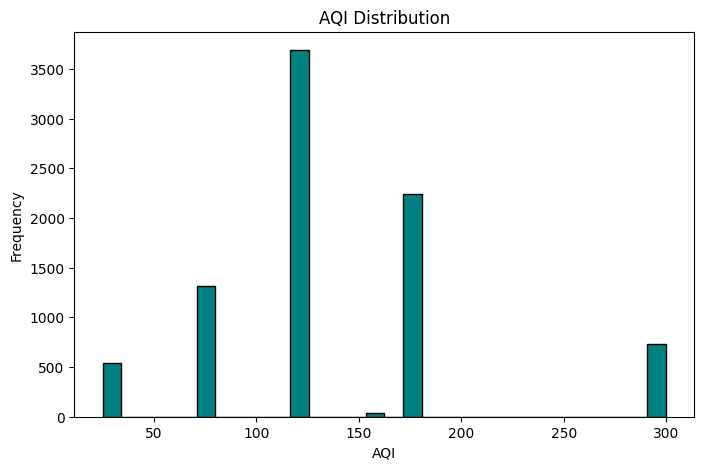

In [119]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["aqi"].dropna(), bins=30, color="teal", edgecolor="black")
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

# AQI category count

2026-05-16 09:54:41,478 WARNING: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



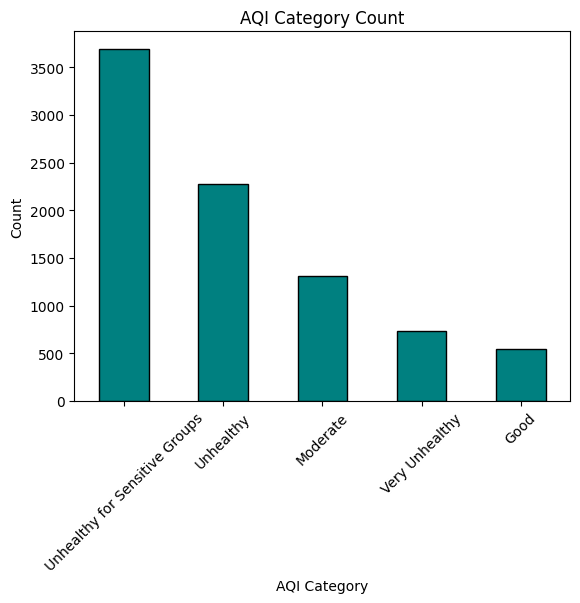

In [120]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df_clean["aqi_category"] = df_clean["aqi"].apply(aqi_category)

df_clean["aqi_category"].value_counts().plot(kind="bar", color="teal", edgecolor="black")
plt.title("AQI Category Count")
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# AQI by day of week

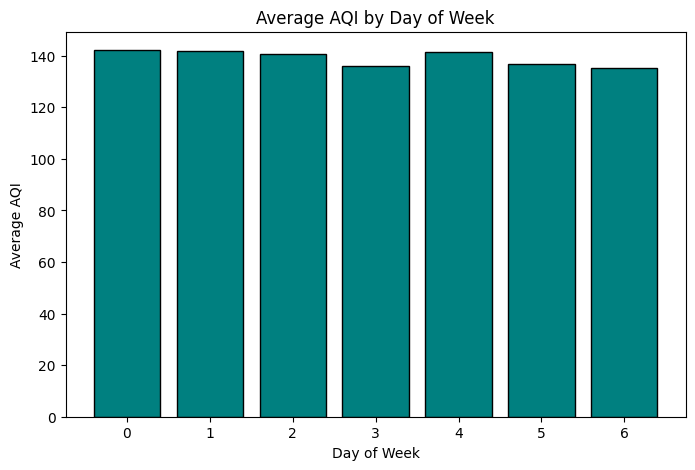

In [121]:
day_aqi = df_clean.groupby("day_of_week")["aqi"].mean()

plt.figure(figsize=(8,5))
plt.bar(day_aqi.index, day_aqi.values, color="teal", edgecolor="black")
plt.title("Average AQI by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average AQI")
plt.show()

# AQI Trend Over Time

2026-05-16 09:54:41,603 WARNING: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



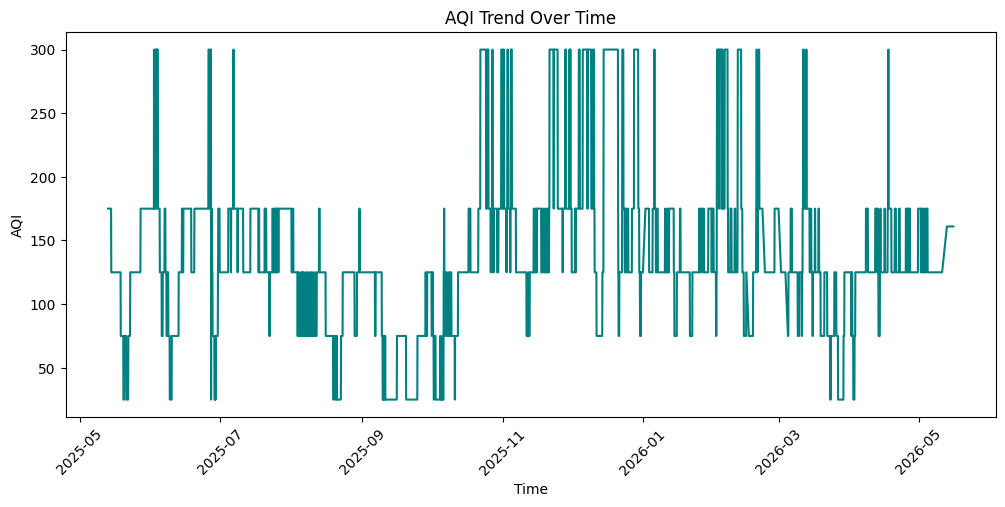

In [122]:
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])

df_sorted = df_clean.sort_values("timestamp")

plt.figure(figsize=(12, 5))
plt.plot(df_sorted["timestamp"], df_sorted["aqi"], color="teal")
plt.title("AQI Trend Over Time")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap

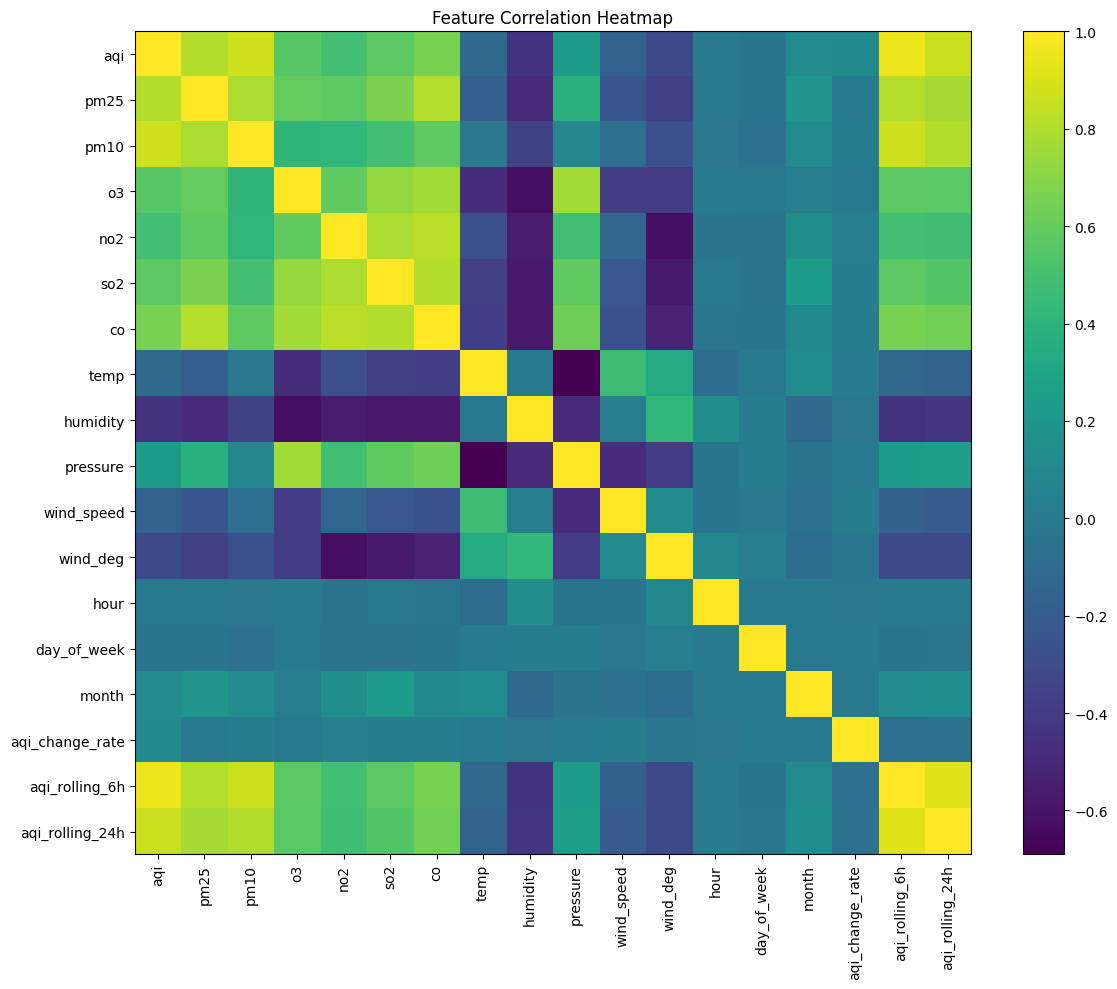

In [123]:
corr_cols = [
    "aqi", "pm25", "pm10", "o3", "no2", "so2", "co",
    "temp", "humidity", "pressure", "wind_speed", "wind_deg",
    "hour", "day_of_week", "month",
    "aqi_change_rate", "aqi_rolling_6h", "aqi_rolling_24h"
]

corr = df_clean[corr_cols].corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="viridis", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [124]:
corr_with_aqi = df_clean.corr(numeric_only=True)["aqi"].sort_values(ascending=False)
corr_with_aqi

aqi                1.000000
aqi_rolling_6h     0.959170
target_aqi_3h      0.918434
pm10               0.877485
aqi_rolling_24h    0.866326
pm25               0.806797
target_aqi_24h     0.658053
co                 0.657690
so2                0.575575
o3                 0.559902
no2                0.495589
target_aqi_72h     0.363181
pressure           0.230848
month_cos          0.230662
month              0.122823
month_sin          0.119931
aqi_change_rate    0.118787
hour_sin           0.013503
hour              -0.006615
is_weekend        -0.031988
hour_cos          -0.032927
day_of_week       -0.033729
temp              -0.106103
wind_speed        -0.155912
wind_deg          -0.317405
humidity          -0.442317
Name: aqi, dtype: float64

# Average AQI by Hour

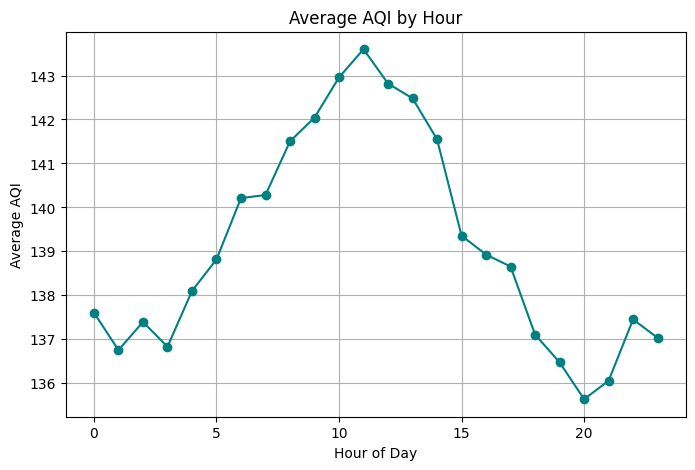

In [125]:
hourly_aqi = df_clean.groupby("hour")["aqi"].mean()
plt.figure(figsize=(8, 5))
plt.plot(hourly_aqi.index, hourly_aqi.values, marker="o", color="teal")
plt.title("Average AQI by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

# Average AQI by Month

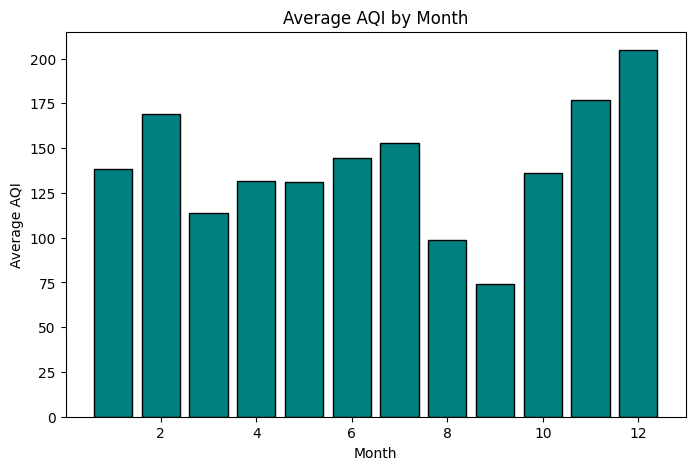

In [126]:
monthly_aqi = df_clean.groupby("month")["aqi"].mean()

plt.figure(figsize=(8, 5))
plt.bar(monthly_aqi.index, monthly_aqi.values, color="teal", edgecolor="black")
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

# Pollutants vs AQI

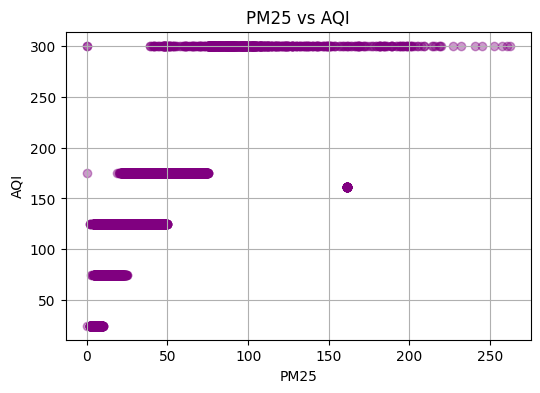

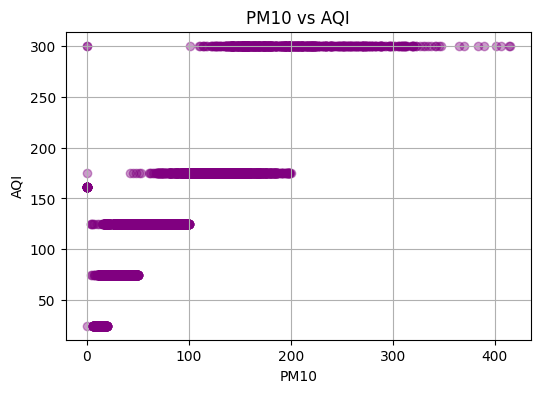

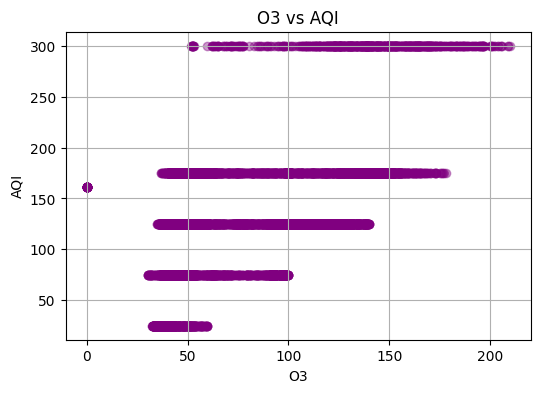

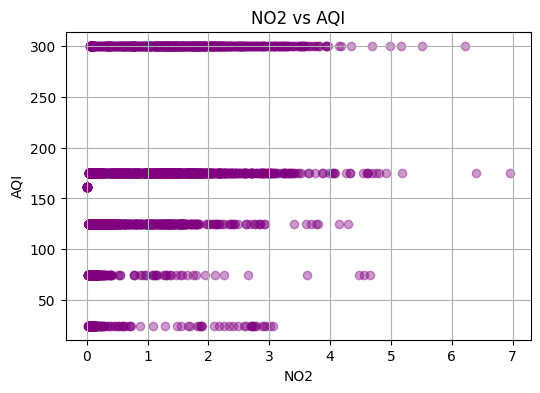

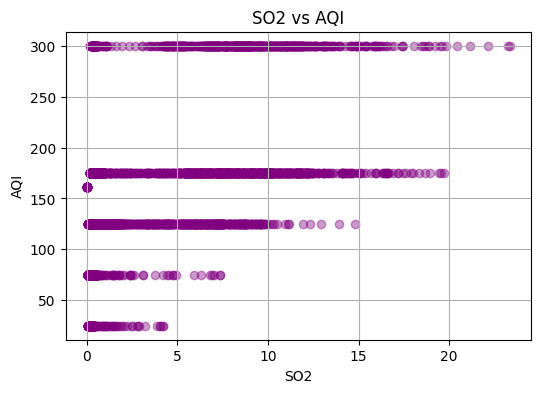

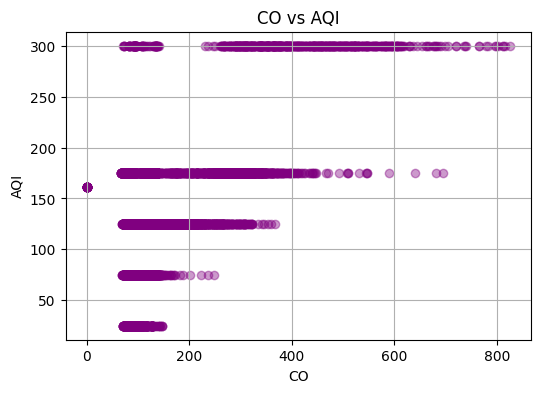

In [127]:
pollutants = ["pm25", "pm10", "o3", "no2", "so2", "co"]

for col in pollutants:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_clean[col], df_clean["aqi"], alpha=0.4, color="purple")
    plt.title(f"{col.upper()} vs AQI")
    plt.xlabel(col.upper())
    plt.ylabel("AQI")
    plt.grid(True)
    plt.show()

# Weather vs AQI

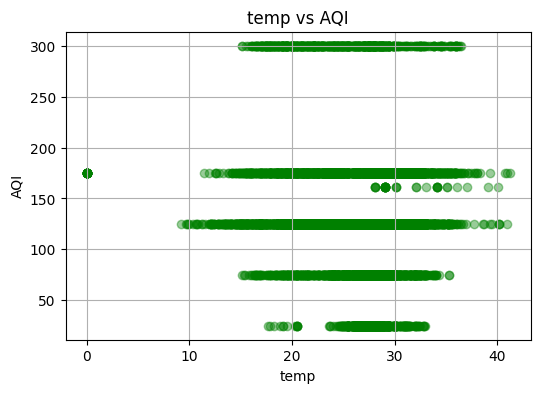

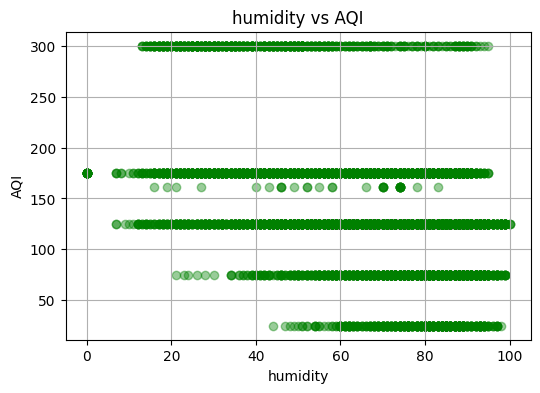

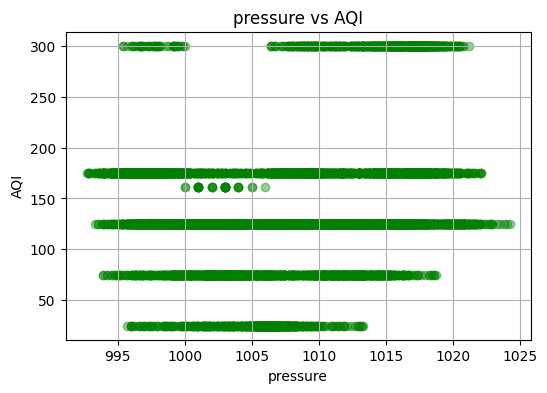

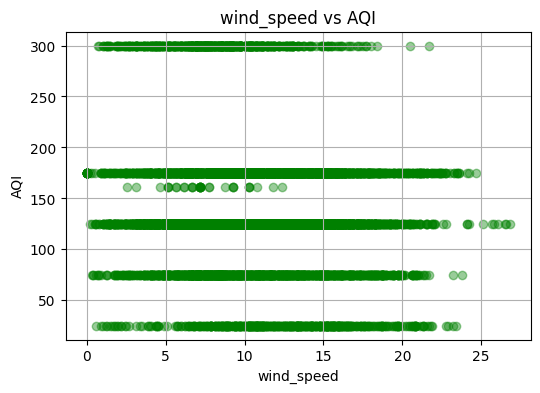

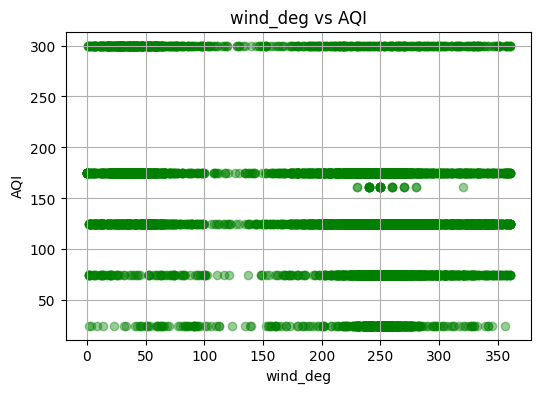

In [128]:
weather_cols = ["temp", "humidity", "pressure", "wind_speed", "wind_deg"]

for col in weather_cols:
    plt.figure(figsize=(6,4))
    plt.scatter(df_clean[col], df_clean["aqi"], alpha=0.4, color="green")
    plt.title(f"{col} vs AQI")
    plt.xlabel(col)
    plt.ylabel("AQI")
    plt.grid(True)
    plt.show()

# Outliers

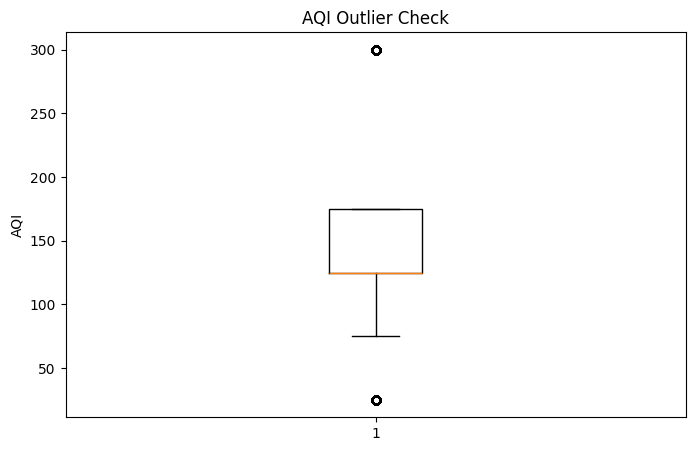

In [129]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean["aqi"].dropna())
plt.title("AQI Outlier Check")
plt.ylabel("AQI")
plt.show()

# Rolling AQI trend

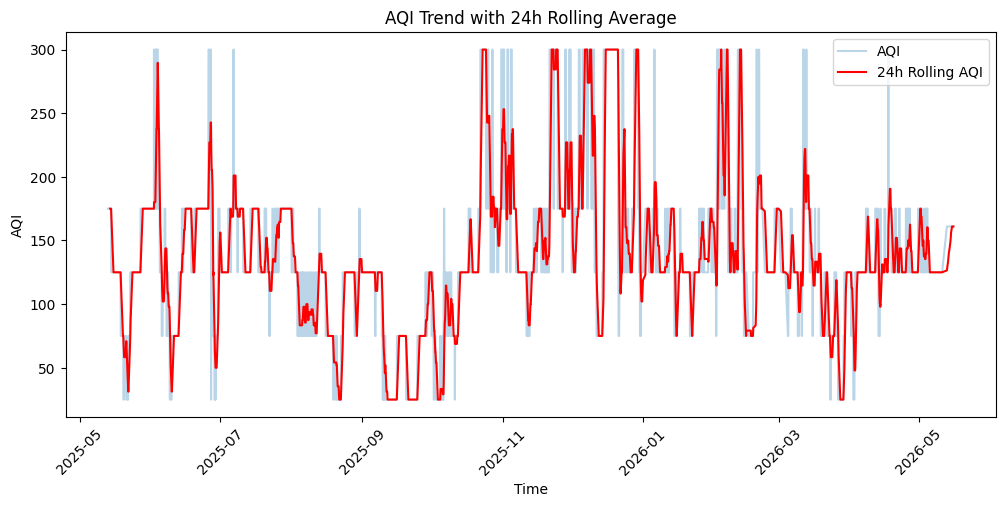

In [130]:
df_sorted = df_clean.sort_values("timestamp")
df_sorted["aqi_rolling_mean"] = df_sorted["aqi"].rolling(24).mean()

plt.figure(figsize=(12,5))
plt.plot(df_sorted["timestamp"], df_sorted["aqi"], alpha=0.3, label="AQI")
plt.plot(df_sorted["timestamp"], df_sorted["aqi_rolling_mean"], color="red", label="24h Rolling AQI")
plt.title("AQI Trend with 24h Rolling Average")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## EDA Findings

- The dataset contains 8,589 rows and 28 engineered features.
- After removing rows with missing future target values, 8,543 clean records remained.
- Missing values were mainly present in future target columns, which is expected because the last records do not have future AQI values.
- AQI values vary over time, which makes forecasting meaningful.
- Pollutants such as PM2.5, PM10, O3, NO2, SO2, and CO were analyzed against AQI.
- Weather features such as temperature, humidity, pressure, wind speed, and wind direction were included because weather affects pollution concentration and movement.
- Correlation analysis showed relationships between pollutant features, rolling AQI values, and AQI.
- SHAP feature importance was used in the dashboard to explain which features influence predictions.

# Model Training and Evaluation


In [131]:
# AQI prediction is a regression problem, so we use MAE, RMSE, and R².
target_col = "target_aqi_72h"
feature_cols = [
    "pm25", "pm10", "o3", "no2", "so2", "co",
    "temp", "humidity", "pressure", "wind_speed", "wind_deg",
    "hour", "day_of_week", "month", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "aqi_change_rate", "aqi_rolling_6h", "aqi_rolling_24h"
]
model_df = df.dropna(subset=feature_cols + [target_col]).copy()

In [132]:
X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6841, 22)
Testing data: (1711, 22)


In [133]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [134]:
linear_preds = linear_model.predict(X_test)

In [135]:
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_r2 = r2_score(y_test, ridge_preds)

print("Ridge Regression Results")
print("MAE:", round(ridge_mae, 3))
print("RMSE:", round(ridge_rmse, 3))
print("R²:", round(ridge_r2, 3))

Ridge Regression Results
MAE: 57.792
RMSE: 73.18
R²: -0.292


In [136]:
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

Ridge()

In [137]:
ridge_preds = ridge_model.predict(X_test)

In [138]:
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_r2 = r2_score(y_test, ridge_preds)

print("Ridge Regression Results")
print("MAE:", round(ridge_mae, 3))
print("RMSE:", round(ridge_rmse, 3))
print("R²:", round(ridge_r2, 3))

Ridge Regression Results
MAE: 42.218
RMSE: 55.637
R²: 0.253


In [139]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [140]:
rf_preds = rf_model.predict(X_test)

In [141]:
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Results")
print("MAE:", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²:", round(rf_r2, 3))

Random Forest Results
MAE: 12.254
RMSE: 21.63
R²: 0.887


In [142]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [143]:
gb_preds = gb_model.predict(X_test)

In [144]:
gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)

print("Gradient Boosting Results")
print("MAE:", round(gb_mae, 3))
print("RMSE:", round(gb_rmse, 3))
print("R²:", round(gb_r2, 3))

Gradient Boosting Results
MAE: 30.646
RMSE: 41.322
R²: 0.588


# Model Comparision

In [145]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        ridge_r2,
        rf_r2,
        gb_r2
    ]
})

results_df = results_df.round(3)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,42.218,55.637,0.253
1,Ridge Regression,42.218,55.637,0.253
2,Random Forest,12.254,21.630,0.887
3,Gradient Boosting,30.646,41.322,0.588


In [146]:
best_model = results_df.sort_values("RMSE").iloc[0]

print("Best Model Based on Lowest RMSE:")
print(best_model)

Best Model Based on Lowest RMSE:
Model    Random Forest
MAE             12.254
RMSE             21.63
R2               0.887
Name: 2, dtype: object


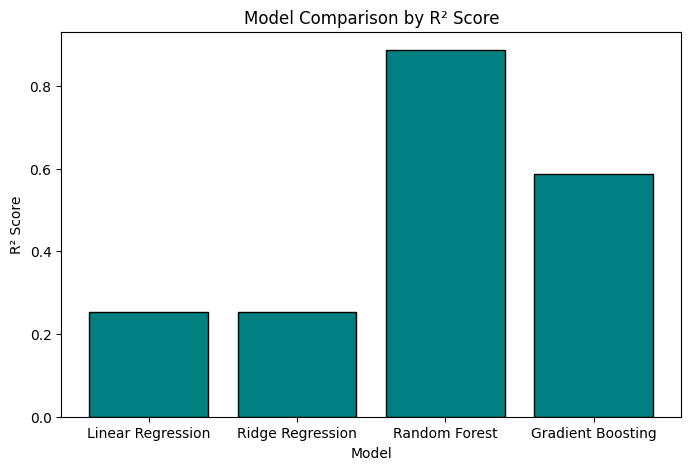

In [147]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2"], color="teal", edgecolor="black")
plt.title("Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.show()

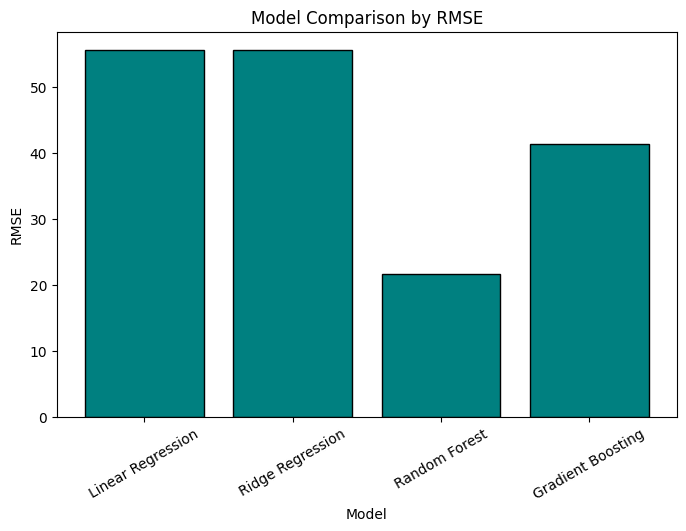

In [148]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"], color="teal", edgecolor="black")
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

# Model Training and Evaluation Finding

Random Forest performed best on the random train-test split in the notebook.

But in the training pipeline Gradient Boosting is selected as a final registered model based on the pipeline evaluation metrics in Hopsworks Model Registry.

Therefore, Gradient Boosting was used as the final production model, while Random Forest was kept as part of the model comparison experiment.